In [30]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn tensorflow keras plotly --quiet
print('All packages installed successfully!')

All packages installed successfully!


In [59]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import (
    train_test_split, TimeSeriesSplit,
    cross_val_score, RandomizedSearchCV
)
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder, MinMaxScaler
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization, Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.2f}'.format)
np.random.seed(42)
tf.random.set_seed(42)

print(f'Libraries loaded | TensorFlow: {tf.__version__}')

Libraries loaded | TensorFlow: 2.20.0


In [60]:
df = pd.read_excel('/content/sample_data/upi_transaction_kaggle.xlsx')
df.head()

,Date,Transaction_type,Category,Description,Amount
0,2021-01-01,Credit,Income,Monthly Salary - NEFT,52000
1,2021-01-01,Debit,Rent,Rent Payment - Landlord,13700
2,2021-01-01,Debit,Food,Morning Juice Bar,90
3,2021-01-01,Debit,Transport,Yulu Cycle,65
4,2021-01-01,Debit,Transport,Namma Yatri,95


In [61]:
df['Date'] = pd.to_datetime(df['Date'])
debit_df   = df[df['Transaction_type'] == 'Debit'].copy()
debit_df['Category'] = debit_df['Description'].apply(assign_broad_category)

debit_df['Year']       = debit_df['Date'].dt.year
debit_df['Month']      = debit_df['Date'].dt.month
debit_df['Quarter']    = debit_df['Date'].dt.quarter
debit_df['DayOfWeek']  = debit_df['Date'].dt.dayofweek
debit_df['IsWeekend']  = (debit_df['DayOfWeek'] >= 5).astype(int)
debit_df['MonthSin']   = np.sin(2 * np.pi * debit_df['Month'] / 12)
debit_df['MonthCos']   = np.cos(2 * np.pi * debit_df['Month'] / 12)

le = LabelEncoder()
debit_df['Category_Enc'] = le.fit_transform(debit_df['Category'])
debit_df.head()

,Date,Transaction_type,Category,Description,Amount,Year,Month,Quarter,DayOfWeek,IsWeekend,MonthSin,MonthCos,Category_Enc
1,2021-01-01,Debit,Utilities,Rent Payment - Landlord,13700,2021,1,1,4,0,0.50,0.87,10
2,2021-01-01,Debit,Other,Morning Juice Bar,90,2021,1,1,4,0,0.50,0.87,6
3,2021-01-01,Debit,Transport,Yulu Cycle,65,2021,1,1,4,0,0.50,0.87,9
4,2021-01-01,Debit,Transport,Namma Yatri,95,2021,1,1,4,0,0.50,0.87,9
5,2021-01-01,Debit,Transport,Ola Cab,95,2021,1,1,4,0,0.50,0.87,9


In [62]:
monthly_cat = (debit_df
               .groupby(['Year', 'Month', 'Quarter', 'Category'])['Amount']
               .sum()
               .reset_index())
monthly_cat.columns = ['Year', 'Month', 'Quarter', 'Category', 'Monthly_Spend']
monthly_cat = monthly_cat.sort_values(['Category', 'Year', 'Month'])

grp = monthly_cat.groupby('Category')['Monthly_Spend']

monthly_cat['Lag_1']      = grp.shift(1)
monthly_cat['Lag_2']      = grp.shift(2)
monthly_cat['Lag_3']      = grp.shift(3)

monthly_cat['Rolling_3m'] = grp.transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())
monthly_cat['Rolling_6m'] = grp.transform(
    lambda x: x.shift(1).rolling(6, min_periods=1).mean())
monthly_cat['Rolling_Std']= grp.transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).std().fillna(0))

monthly_cat['MoM_Change'] = grp.transform(
    lambda x: x.pct_change(fill_method=None).fillna(0))

monthly_cat['MonthSin']    = np.sin(2 * np.pi * monthly_cat['Month'] / 12)
monthly_cat['MonthCos']    = np.cos(2 * np.pi * monthly_cat['Month'] / 12)
monthly_cat['QuarterSin']  = np.sin(2 * np.pi * monthly_cat['Month'].apply(
    lambda m: (m-1)//3 + 1) / 4)
monthly_cat['Category_Enc']= le.transform(monthly_cat['Category'])

for col in ['Lag_1','Lag_2','Lag_3']:
    monthly_cat[col] = monthly_cat[col].fillna(monthly_cat['Rolling_3m'])

monthly_cat.dropna(inplace=True)
monthly_cat.reset_index(drop=True, inplace=True)

monthly_cat.head()

,Year,Month,Quarter,Category,Monthly_Spend,Lag_1,Lag_2,Lag_3,Rolling_3m,Rolling_6m,Rolling_Std,MoM_Change,MonthSin,MonthCos,QuarterSin,Category_Enc
0,2021,6,2,Bills/Rent/Insurance,8200,12500.00,12500.00,12500.00,12500.00,12500.00,0.00,-0.34,0.00,-1.00,0.00,0
1,2022,3,1,Bills/Rent/Insurance,12500,8200.00,12500.00,10350.00,10350.00,10350.00,3040.56,0.52,1.00,0.00,1.00,0
2,2022,6,2,Bills/Rent/Insurance,8200,12500.00,8200.00,12500.00,11066.67,11066.67,2482.61,-0.34,0.00,-1.00,0.00,0
3,2023,3,1,Bills/Rent/Insurance,12500,8200.00,12500.00,8200.00,9633.33,10350.00,2482.61,0.52,1.00,0.00,1.00,0
4,2023,6,2,Bills/Rent/Insurance,8200,12500.00,8200.00,12500.00,11066.67,10780.00,2482.61,-0.34,0.00,-1.00,0.00,0


In [63]:
FEATURES = ['Year', 'Month', 'Quarter', 'Category_Enc',
            'Lag_1', 'Lag_2', 'Lag_3',
            'Rolling_3m', 'Rolling_6m', 'Rolling_Std',
            'MoM_Change', 'MonthSin', 'MonthCos', 'QuarterSin']
TARGET   = 'Monthly_Spend'

X = monthly_cat[FEATURES].values
y_raw = monthly_cat[TARGET].values
y = np.log1p(y_raw)

monthly_cat_sorted = monthly_cat.sort_values(['Year', 'Month'])
split_n = int(len(monthly_cat_sorted) * 0.80)
train_idx = monthly_cat_sorted.index[:split_n]
test_idx  = monthly_cat_sorted.index[split_n:]

X_train = X[monthly_cat.index.isin(train_idx)]
X_test  = X[monthly_cat.index.isin(test_idx)]
y_train = y[monthly_cat.index.isin(train_idx)]
y_test  = y[monthly_cat.index.isin(test_idx)]

y_test_raw  = np.expm1(y_test)
y_train_raw = np.expm1(y_train)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


In [64]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te,
                   y_te_raw, use_scaled=True):

    Xtr = X_tr if use_scaled else X_train
    Xte = X_te if use_scaled else X_test

    model.fit(Xtr, y_tr)
    y_pred_log = model.predict(Xte)
    y_pred_inr = np.expm1(np.clip(y_pred_log, 0, None))

    mae  = mean_absolute_error(y_te_raw, y_pred_inr)
    rmse = np.sqrt(mean_squared_error(y_te_raw, y_pred_inr))
    r2   = r2_score(y_te_raw, y_pred_inr)

    tscv = TimeSeriesSplit(n_splits=5)
    cv_r2 = cross_val_score(
        model, Xtr, y_tr,
        cv=tscv, scoring='r2', n_jobs=-1
    ).mean()

    print(f'\n{"─"*50}')
    print(f' {name}')
    print(f'{"─"*50}')
    print(f'  MAE    : ₹{mae:,.2f}')
    print(f'  RMSE   : ₹{rmse:,.2f}')
    print(f'  R²     : {r2:.4f}')

    return {
        'Model': name, 'MAE': mae, 'RMSE': rmse,
        'R2': r2, 'CV_R2': cv_r2,
        'Predictions': y_pred_inr
    }


ml_results = {}

# ── 1. Ridge Regression ────────
ridge = Ridge(alpha=10.0)
ml_results['Ridge Regression'] = evaluate_model(
    'Ridge Regression', ridge,
    X_train_sc, X_test_sc,
    y_train, y_test, y_test_raw,
    use_scaled=True
)

# ── 2. Decision Tree ─────────────────────────────────────────────
dt = DecisionTreeRegressor(
    max_depth=5, min_samples_split=4,
    min_samples_leaf=2, random_state=42
)
ml_results['Decision Tree'] = evaluate_model(
    'Decision Tree', dt,
    X_train, X_test,
    y_train, y_test, y_test_raw,
    use_scaled=False
)

# ── 3. Random Forest ─────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=300, max_depth=8,
    min_samples_split=4, min_samples_leaf=2,
    max_features='sqrt', random_state=42, n_jobs=-1
)
ml_results['Random Forest'] = evaluate_model(
    'Random Forest', rf,
    X_train, X_test,
    y_train, y_test, y_test_raw,
    use_scaled=False
)

# ── 4. Gradient Boosting ─────────────────────────────────────────
gb = GradientBoostingRegressor(
    n_estimators=300, max_depth=4,
    learning_rate=0.03, subsample=0.8,
    min_samples_split=4, random_state=42
)
ml_results['Gradient Boosting'] = evaluate_model(
    'Gradient Boosting', gb,
    X_train, X_test,
    y_train, y_test, y_test_raw,
    use_scaled=False
)

# ── 5. XGBoost ───────────────────────────────────────────────────
xgb = XGBRegressor(
    n_estimators=300, max_depth=4,
    learning_rate=0.03, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1,
    reg_lambda=1.0, random_state=42, verbosity=0
)
ml_results['XGBoost'] = evaluate_model(
    'XGBoost', xgb,
    X_train, X_test,
    y_train, y_test, y_test_raw,
    use_scaled=False
)


──────────────────────────────────────────────────
 Ridge Regression
──────────────────────────────────────────────────
  MAE    : ₹9,948.33
  RMSE   : ₹18,852.39
  R²     : 0.2666

──────────────────────────────────────────────────
 Decision Tree
──────────────────────────────────────────────────
  MAE    : ₹5,944.92
  RMSE   : ₹11,051.61
  R²     : 0.7480

──────────────────────────────────────────────────
 Random Forest
──────────────────────────────────────────────────
  MAE    : ₹5,785.72
  RMSE   : ₹13,055.69
  R²     : 0.6483

──────────────────────────────────────────────────
 Gradient Boosting
──────────────────────────────────────────────────
  MAE    : ₹2,427.18
  RMSE   : ₹6,457.74
  R²     : 0.9139

──────────────────────────────────────────────────
 XGBoost
──────────────────────────────────────────────────
  MAE    : ₹3,128.71
  RMSE   : ₹7,326.24
  R²     : 0.8892


In [65]:
# ─── ML Results Summary Table ────────────────────────────────────
ml_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'Predictions'}
    for r in ml_results.values()
]).sort_values('R2', ascending=False).reset_index(drop=True)

print('\n ML Model Comparison Table (metrics in ₹):')
print(ml_df.to_string(index=False))


 ML Model Comparison Table (metrics in ₹):
            Model     MAE     RMSE   R2  CV_R2
Gradient Boosting 2427.18  6457.74 0.91   0.68
          XGBoost 3128.71  7326.24 0.89   0.52
    Decision Tree 5944.92 11051.61 0.75   0.46
    Random Forest 5785.72 13055.69 0.65   0.14
 Ridge Regression 9948.33 18852.39 0.27  -0.51


In [66]:
_model_map = {
    'Ridge Regression': ridge,
    'Decision Tree': dt,
    'Random Forest': rf,
    'Gradient Boosting': gb,
    'XGBoost': xgb
}

DL model

In [68]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

raw_df = pd.read_excel('/content/sample_data/upi_transaction_kaggle.xlsx')

raw_df['Date'] = pd.to_datetime(raw_df['Date'])

debit_df = raw_df[raw_df['Transaction_type'] == 'Debit'].copy()

monthly_spend_df = debit_df.groupby(pd.Grouper(key='Date', freq='MS'))['Amount'].sum().reset_index()
monthly_spend_df.rename(columns={'Amount': 'Monthly_Spend'}, inplace=True);

monthly_spend_df['Year'] = monthly_spend_df['Date'].dt.year
monthly_spend_df['Month'] = monthly_spend_df['Date'].dt.month
monthly_spend_df['Quarter'] = monthly_spend_df['Date'].dt.quarter
monthly_spend_df['MonthSin'] = np.sin(2 * np.pi * monthly_spend_df['Month'] / 12)
monthly_spend_df['MonthCos'] = np.cos(2 * np.pi * monthly_spend_df['Month'] / 12)

df = monthly_spend_df.copy()

df['Lag_1'] = df['Monthly_Spend'].shift(1)
df['Lag_2'] = df['Monthly_Spend'].shift(2)
df['Lag_3'] = df['Monthly_Spend'].shift(3)

df['Rolling_3'] = df['Monthly_Spend'].rolling(3).mean()
df['Rolling_6'] = df['Monthly_Spend'].rolling(6).mean()

df = df.dropna()

FEATURES = [
    'Monthly_Spend', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_3', 'Rolling_6',
    'Year', 'Month', 'Quarter', 'MonthSin', 'MonthCos'
]
TARGET = 'Monthly_Spend'

X = df[FEATURES]
y = df[TARGET]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

def create_sequences(X, y, time_steps=12):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 12
X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)

split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

model = Sequential()

model.add(LSTM(256, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))

model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(64))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(patience=7, restore_best_weights=True)

model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

y_pred = model.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred)
y_test = scaler_y.inverse_transform(y_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n===== IMPROVED LSTM =====")
print(f"MAE  : ₹{mae:.2f}")
print(f"RMSE : ₹{rmse:.2f}")
print(f"R2   : {r2:.4f}")

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 789ms/step - loss: 0.1253 - val_loss: 0.0151
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 0.0605 - val_loss: 0.0114
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 0.0541 - val_loss: 0.0211
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - loss: 0.0696 - val_loss: 0.0129
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - loss: 0.0591 - val_loss: 0.0126
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.0534 - val_loss: 0.0143
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - loss: 0.0636 - val_loss: 0.0214
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - loss: 0.0487 - val_loss: 0.0223
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - loss: 0.0435 - val_loss: 0.0190
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 664ms/step

===== IMPROVED LSTM =====
MAE  : ₹47469.11
RMSE : ₹56556.20
R2   : 0.0190


In [73]:
# ─── Full Comparison Table ────────────────────────────────────────
comparison_data = []
for name, result in ml_results.items():
    comparison_data.append({
        'Model': name, 'Type': 'ML',
        'MAE':  round(result['MAE'],  2),
        'RMSE': round(result['RMSE'], 2),
        'R2':   round(result['R2'],   4)
    })
comparison_data.append({
    'Model': 'LSTM (Sequential)',
    'Type': 'DL',
    'MAE':  round(mae,  2),
    'RMSE': round(rmse, 2),
    'R2':   round(r2,   4)
})

comp_df = pd.DataFrame(comparison_data).sort_values('R2', ascending=False)
print('\n  FULL MODEL COMPARISON (all metrics in ₹):')
print(comp_df.to_string(index=False))

best_model_name = comp_df[comp_df['Type']=='ML'].iloc[0]['Model']
print(f'\n Best ML Model: {best_model_name}')
print(f' LSTM R²: {r2:.4f}')


  FULL MODEL COMPARISON (all metrics in ₹):
            Model Type      MAE     RMSE   R2
Gradient Boosting   ML  2427.18  6457.74 0.91
          XGBoost   ML  3128.71  7326.24 0.89
    Decision Tree   ML  5944.92 11051.61 0.75
    Random Forest   ML  5785.72 13055.69 0.65
 Ridge Regression   ML  9948.33 18852.39 0.27
LSTM (Sequential)   DL 47469.11 56556.20 0.02

 Best ML Model: Gradient Boosting
 LSTM R²: 0.0190


In [74]:
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=('MAE Comparison', 'RMSE Comparison', 'R2 Score Comparison'))

# MAE Comparison
fig.add_trace(go.Bar(name='MAE', x=comp_df['Model'], y=comp_df['MAE'],
                     marker_color='blue'), row=1, col=1)

# RMSE Comparison
fig.add_trace(go.Bar(name='RMSE', x=comp_df['Model'], y=comp_df['RMSE'],
                     marker_color='red'), row=1, col=2)

# R2 Score Comparison
fig.add_trace(go.Bar(name='R2', x=comp_df['Model'], y=comp_df['R2'],
                     marker_color='green'), row=1, col=3)

fig.update_layout(title_text='Model Performance Comparison', height=500, showlegend=False)
fig.show()

In [75]:
best_ml_model_predictions = ml_results[best_model_name]['Predictions']

fig = go.Figure()
fig.add_trace(go.Scatter(
    y=y_test_raw,
    mode='lines',
    name='Actual Values',
    line=dict(color='blue', width=2)
))
fig.add_trace(go.Scatter(
    y=best_ml_model_predictions,
    mode='lines',
    name='Predicted Values',
    line=dict(color='red', width=2, dash='dash')
))

fig.update_layout(
    title=f'{best_model_name}: Actual vs. Predicted Monthly Spend',
    xaxis_title='Time Step',
    yaxis_title='Monthly Spend (₹)',
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

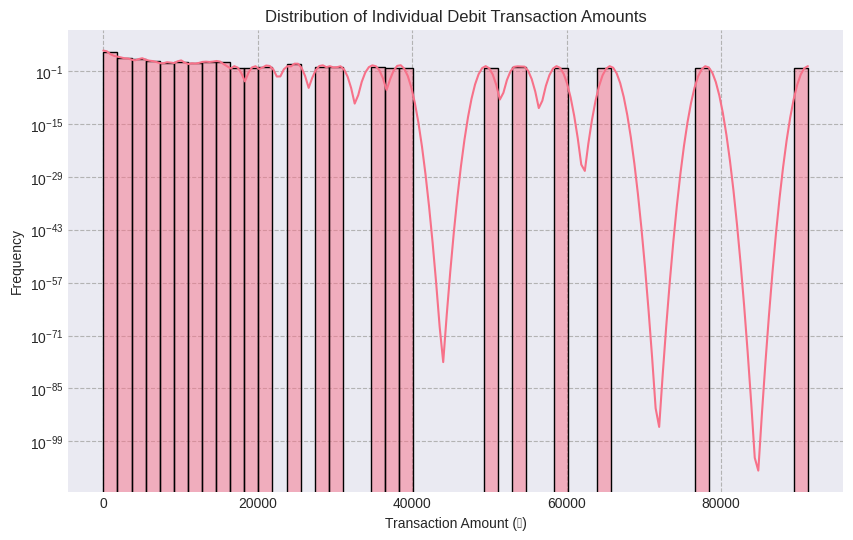

In [77]:
fig = plt.figure(figsize=(10, 6))
sns.histplot(debit_df['Amount'], bins=50, kde=True)
plt.title('Distribution of Individual Debit Transaction Amounts')
plt.xlabel('Transaction Amount (₹)')
plt.ylabel('Frequency')
plt.yscale('log') # Use a log scale for y-axis if there's a wide range
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()

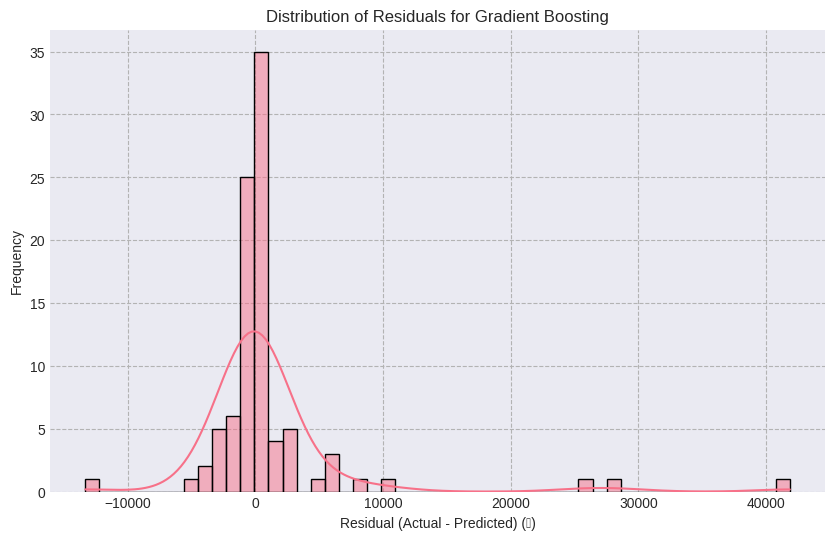

In [78]:
residuals = y_test_raw - best_ml_model_predictions

fig = plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True)
plt.title(f'Distribution of Residuals for {best_model_name}')
plt.xlabel('Residual (Actual - Predicted) (₹)')
plt.ylabel('Frequency')
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()

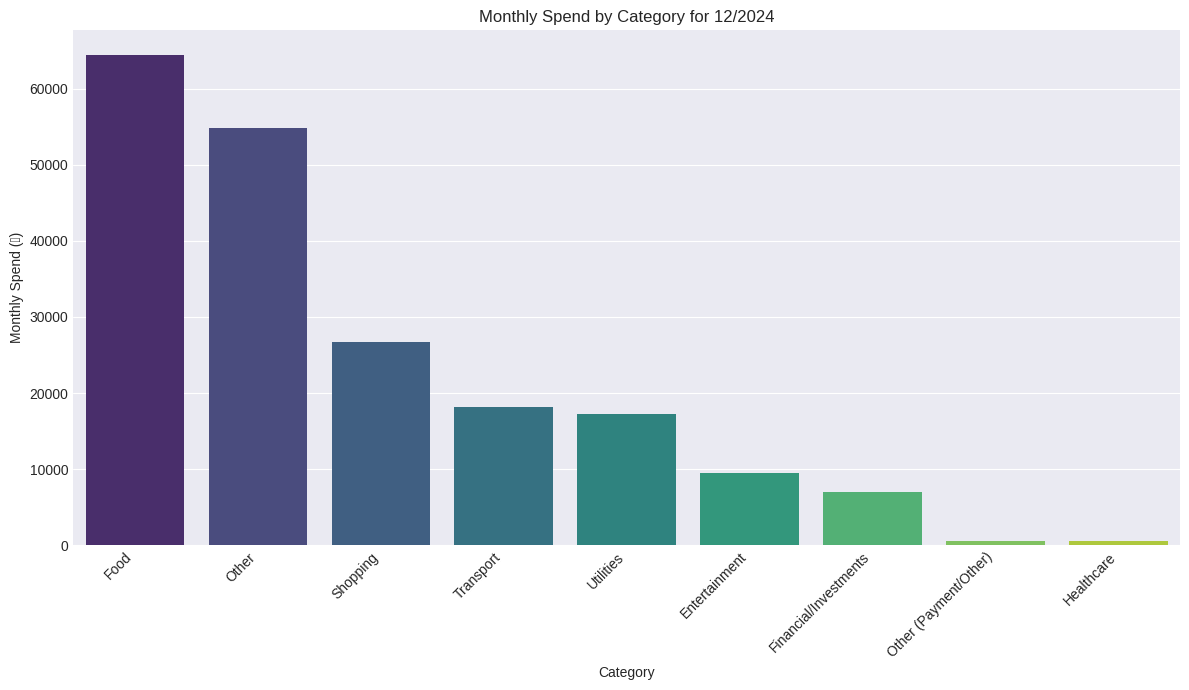

In [79]:
latest_month = monthly_cat[['Year', 'Month']].max().values
latest_year = latest_month[0]
latest_month_num = latest_month[1]

latest_month_data = monthly_cat[(monthly_cat['Year'] == latest_year) & (monthly_cat['Month'] == latest_month_num)]

fig = plt.figure(figsize=(12, 7))
sns.barplot(x='Category', y='Monthly_Spend', data=latest_month_data.sort_values('Monthly_Spend', ascending=False), palette='viridis')
plt.title(f'Monthly Spend by Category for {latest_month_num}/{latest_year}')
plt.xlabel('Category')
plt.ylabel('Monthly Spend (₹)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

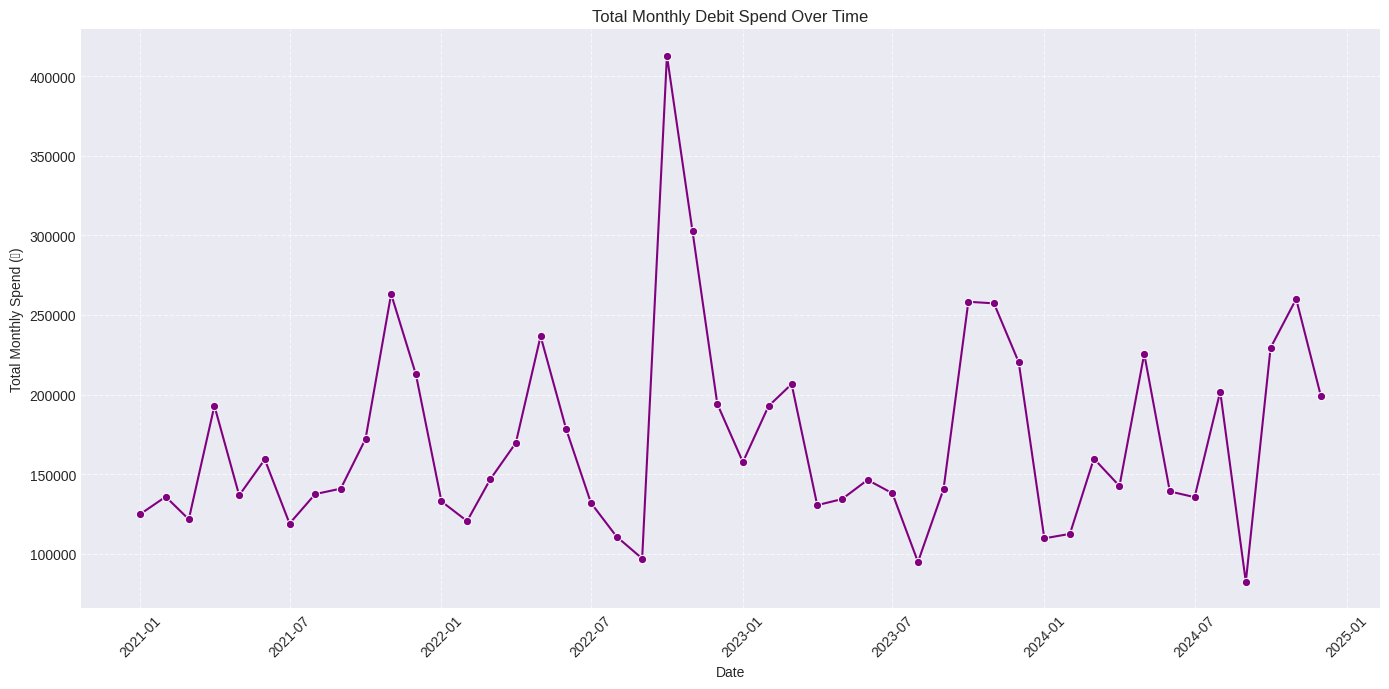

In [80]:
monthly_total_spend = debit_df.groupby(pd.Grouper(key='Date', freq='MS'))['Amount'].sum().reset_index()
monthly_total_spend.rename(columns={'Amount': 'Total_Spend'}, inplace=True)

fig = plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Total_Spend', data=monthly_total_spend, marker='o', color='purple')
plt.title('Total Monthly Debit Spend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Monthly Spend (₹)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()